In [138]:
from PyAstronomy.pyasl import foldAt
import matplotlib.pylab as plt
import numpy as np

from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt 

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk


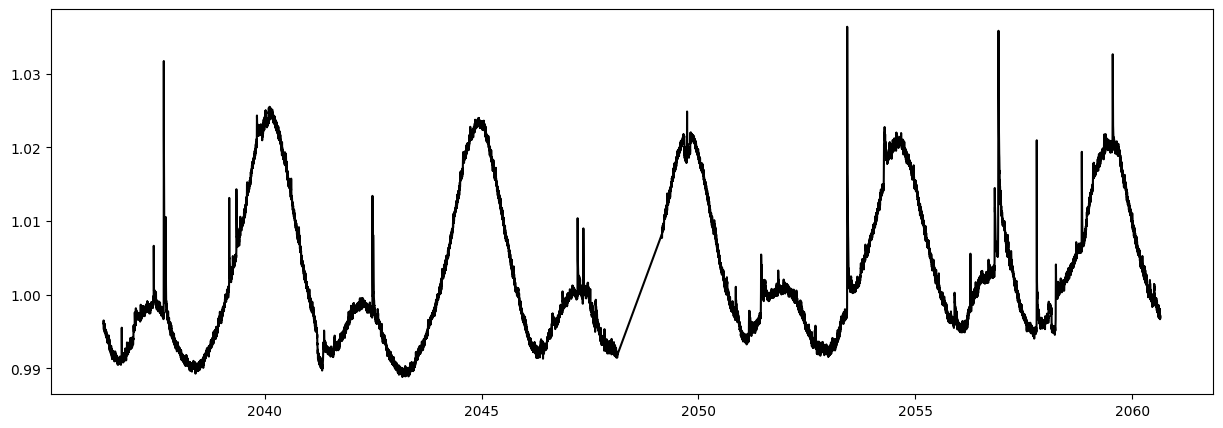

In [139]:
search_result = search_lightcurve("AU Mic") 
lc2min = search_result[8].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()

x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

# Generate some data ...
time = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
flux = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
# ... and add some noise
#flux += np.random.normal(0, 0.02, len(flux))

fig,ax = plt.subplots(1,1,figsize=(15,5))

plt.plot(time, flux, 'k')


1.0363554954528809


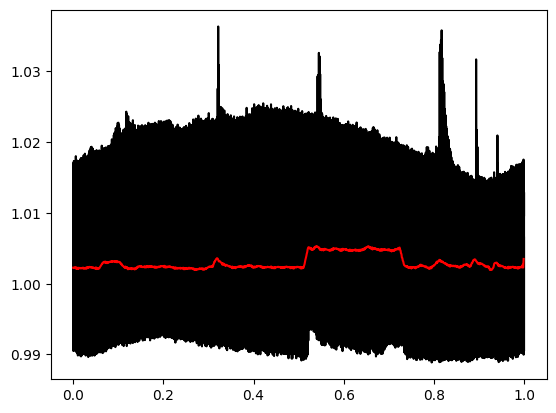

In [143]:
t0 = 2454966.3304
t0_in_bkjd = t0 - 2454833
phases = foldAt(time,4.829, T0=t0_in_bkjd)
# Sort with respect to phase
# First, get the order of indices ...
sortIndi = np.argsort(phases)
# ... and, second, rearrange the arrays.
phases = phases[sortIndi]
flux = flux[sortIndi]

phases_med =[]
x_med = [i/1000 for i in range(1000)]
for fase in x_med:
	aux = 0
	aux_2 = 0
	for i in range(len(phases)): 
		if phases[i]>fase and phases[i]<fase+0.01:
			aux += flux[i]
			aux_2 += 1
	phases_med.append(aux/aux_2)

plt.plot(phases, flux, 'k')
#plt.scatter(phases, flux)
plt.plot(x_med, phases_med, 'r-', label = 'median value')
#plt.scatter(phases, flux, color='black',  marker='o',  linestyle='dotted', label='Pontos')
#plt.plot(phases, flux, color='black', linestyle='-', label='Linha')
print(np.max(flux))

In [141]:
#dados parâmetros###
dados_1=np.loadtxt('temp_ener_s27_2min.txt')

temp_med = dados_1[:,0]
ener_setor1 = dados_1[:,1]
enerlog10 = np.log10(ener_setor1)
print(len(temp_med))

37


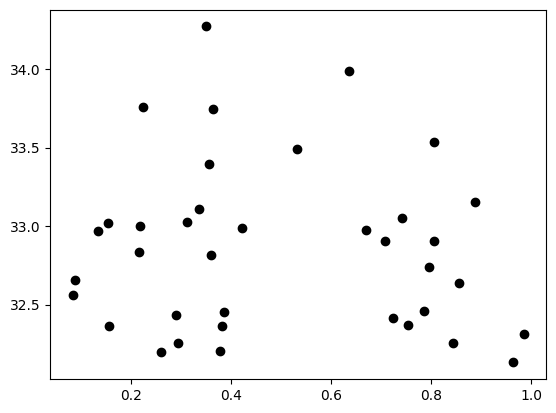

In [134]:
t0 = 2454966.3304
t0_in_bkjd = t0 - 2454833

fase1 = foldAt(temp_med,4.829, T0=t0_in_bkjd)
plt.plot(fase1, enerlog10, 'ko')


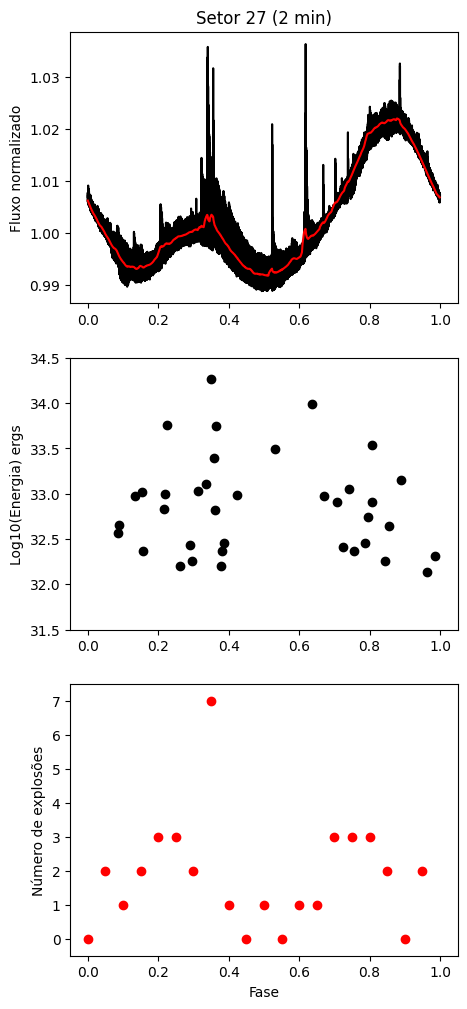

In [142]:
fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize=(5,12))

ax1.set_title('Setor 27 (2 min)')
ax1.plot(phases, flux, 'k',x_med, phases_med, 'r-')
ax1.set_ylabel('Fluxo normalizado')
ax2.plot(fase1, enerlog10, 'ko')
ax2.set_ylabel('Log10(Energia) ergs')
ax3.plot(x_med0, phases_med0, 'ro')
#ax3.set_ylabel('Relative flux [ppt]')
ax1.set_xlim(-0.050,1.050)
ax2.set_xlim(-0.050,1.050)
ax3.set_xlim(-0.050,1.050)

#ax1.set_ylim(0.98,1.055)
ax2.set_ylim(31.5,34.5)
ax3.set_ylim(-0.5,7.5)


ax3.set_xlabel('Fase')
ax3.set_ylabel('Número de explosões')
plt.show()

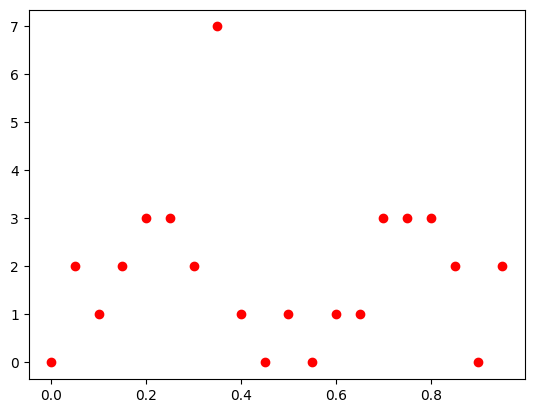

In [136]:
phases1 = foldAt(temp_med,4.829, T0=t0_in_bkjd)
# Sort with respect to phase
# First, get the order of indices ...
sortIndi = np.argsort(phases1)
# ... and, second, rearrange the arrays.
flux = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)

phases1 = phases1[sortIndi]
flux = flux[sortIndi]


phases_med0 =[]
x_med0 = [i/20 for i in range(20)]
for fase in x_med0:
	aux = 0
	aux_2 = 0
	for i in range(len(phases1)): 
		if phases1[i]>fase and phases1[i]<fase+0.05:
			aux += flux[i]
			aux_2 += 1
	phases_med0.append(aux_2)

plt.plot(x_med0, phases_med0, 'ro')